In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.oscprob.oscprobstd as oscprobstd
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.matter as matter
import magnus.globaldefs as gd

Biprobability plots show how neutrino vs. anti-neutrino oscillation probabilities change as a function of the CP-violation phase, $\delta_{\rm CP}$.  This is typically done for neutrino propagation in matter, representing the setup of long-baseline neutrino oscillations in which $\delta_{\rm CP}$ is expected to be measured.  Biprobability plots are useful to illustrate the separation between neutrino and anti-neutrino oscillation probabilities from which this measurement is performed.

Sometimes, biprobability plots include new-physics effects that affect the probabilities, in order to show how their presence could cloud the measurement of $\delta_{\rm CP}$.  In this notebook, we use Mag$\nu$s to produce biprobability plots only under standard $3\nu$ oscillations; for biprobability plots including sterile neutrinos and non-standard interactions, see notebooks `07_magnus_bsm_sterile_nu.ipynb` and `08_magnus_bsm_nsi.ipynb`, respectively.

## Plotting function and general definitions

First, let's define a general-purpose plotting function to produce biprobability plots, given precomputed neutrino and anti-neutrino oscillation probabilities:

In [88]:
def make_plot_biprobability(prob_nu_arr, prob_nubar_arr, ls, lc, lw, label_prob_nu, label_prob_nubar, points_sel_arr=None,
                            annotations=None, xaxis_major_locator=None, xaxis_minor_locator=None, 
                            yaxis_major_locator=None, yaxis_minor_locator=None, leg_fontsize=16, leg_loc=None, leg_ncol=1, 
                            xlim=None, ylim=None, save_fig=False, fig_filename=None, fig_format='pdf'):

    heights = [1.0]
    widths = [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[9,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    # Plot the curves of prob_nu vs. prob_nubar for varying dCP
    for i in range(len(prob_nu_arr)):
        ax.plot(prob_nu_arr[i][:,1], prob_nubar_arr[i][:,1], lw=lw[i], c=lc[i], ls=ls[i])

    # Mark the points of selected values of dCP
    if points_sel_arr is not None:
        for i, points_sel in enumerate(points_sel_arr):
            for p in points_sel:
                ax.scatter(p[3][0], p[3][1], marker=p[1], ls='-', edgecolors=lc[i], s=70, c=lc[i] if p[2] == True else 'none')
        
    # Legend
    if points_sel_arr is not None:
        for p in points_sel_arr[0]: # Points at fake positions, just for the legend
            ax.scatter(-10, -10, marker=p[1], ls='-', edgecolors='k', label=p[0], s=70, c='k' if p[2] == True else 'none')
        ax.legend(fontsize=leg_fontsize, frameon=True, loc=leg_loc if leg_loc is not None else None, handlelength=1.2, handleheight=0.7,
                  borderpad=0.8, title_fontsize=18, edgecolor='k', labelspacing=0.7, ncol=leg_ncol, title=r'$\delta_{\rm CP}$')

    # Annotations
    if annotations is not None:
        for annotation in annotations:
            ax.annotate(annotation['text'], xy=annotation['xy'], fontsize=annotation['fontsize'], color=annotation['color'],
                        ha=annotation['ha'], xycoords='axes fraction')

    # Formatting
    if xlim is not None:
        ax.set_xlim(xlim)
    if xlim is not None:
        ax.set_ylim(ylim)
    if xaxis_major_locator is not None:
        ax.xaxis.set_major_locator(xaxis_major_locator)
    if xaxis_minor_locator is not None:
        ax.xaxis.set_minor_locator(xaxis_minor_locator)
    if yaxis_major_locator is not None:
        ax.yaxis.set_major_locator(yaxis_major_locator)
    if yaxis_minor_locator is not None:
        ax.yaxis.set_minor_locator(yaxis_minor_locator)
    ax.set_xlabel(label_prob_nu)
    ax.set_ylabel(label_prob_nubar)

    # Save plot
    if save_fig:
        plt.savefig(fig_filename+'.'+fig_format, transparent=False, bbox_inches='tight', dpi=300)

## In vacuum

Let's start with the case of propagation in vacuum, comparing the plots obtained under normal mass ordering (NO) and under inverted mass ordering (IO).  In each case, we fix the mixing parameters to their best-fit values from the NuFit 6.0 global fit to oscillation data, which are stored in the `globaldefs` module of Mag$\nu$s.

In [ ]:
# Mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12_NO = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23_NO = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13_NO = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP_NO = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21_NO = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31_NO = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]
s12_IO = gd.S12_IO_BF_NUFIT_6_0 # [adim]
s23_IO = gd.S23_IO_BF_NUFIT_6_0 # [adim]
s13_IO = gd.S13_IO_BF_NUFIT_6_0 # [adim]
dCP_IO = gd.DCP_IO_BF_NUFIT_6_0 # [adim]
D21_IO = gd.D21_IO_BF_NUFIT_6_0 # [eV^2]
D31_IO = gd.D31_IO_BF_NUFIT_6_0 # [eV^2]

In [86]:
# Pick the baseline and energy of T2K
baseline = 810 # [km]
energy = 2*gd.UNIT_MEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Hamiltonian in vacuum for neutrinos
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False)

# Hamiltonian in vacuum for anti-neutrinos
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False)

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

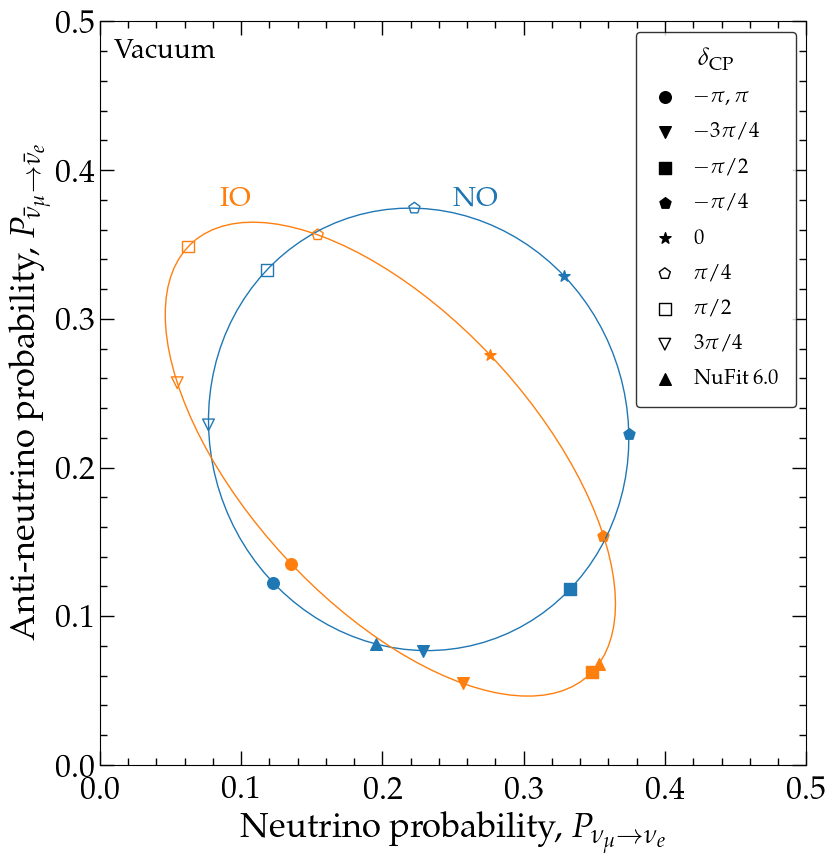

In [89]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '-'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': 'Vacuum', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'NO', 'xy': (0.5,0.75), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.17,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'}
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0,0.50], ylim=[0,0.50], save_fig=False)

To validate this result, which was produced using the Mag$\nu$s expansion (albeit, to first order only, since for propoagation in vacuum this is enough), we compute the biprobability using the standard $3\nu$ oscillation probability instead.

In [91]:
# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob_3nu_vacuum_std returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
prob_nu_std_NO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians3nu.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP),
                                                                          D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                          nubar=False)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_std_NO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians3nu.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP),
                                                                             D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                             nubar=True)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_std_IO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians3nu.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP),
                                                                          D21_IO, D31_IO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                          nubar=False)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_std_IO = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(hamiltonians3nu.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP),
                                                                             D21_IO, D31_IO, energy, baseline*gd.CONV_KM_TO_INV_EV,
                                                                             nubar=True)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_std_NO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians3nu.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=False)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_std_NO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians3nu.pmns_mixing_matrix(s12_NO, s23_NO, s13_NO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=True)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_std_IO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians3nu.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=False)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_std_IO_sel = np.array([[dCP/np.pi, oscprobstd.osc_prob_3nu_vacuum_std(
    hamiltonians3nu.pmns_mixing_matrix(s12_IO, s23_IO, s13_IO, dCP), D21_NO, D31_NO, energy, baseline*gd.CONV_KM_TO_INV_EV, 
    nubar=True)[nu_i][nu_f]] for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
points_std_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_std_NO_sel[i][1], prob_nubar_std_NO_sel[i][1]]] 
                     for i in range(len(dCP_sel)+1)]
points_std_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_std_IO_sel[i][1], prob_nubar_std_IO_sel[i][1]]] 
                     for i in range(len(dCP_sel)+1)]

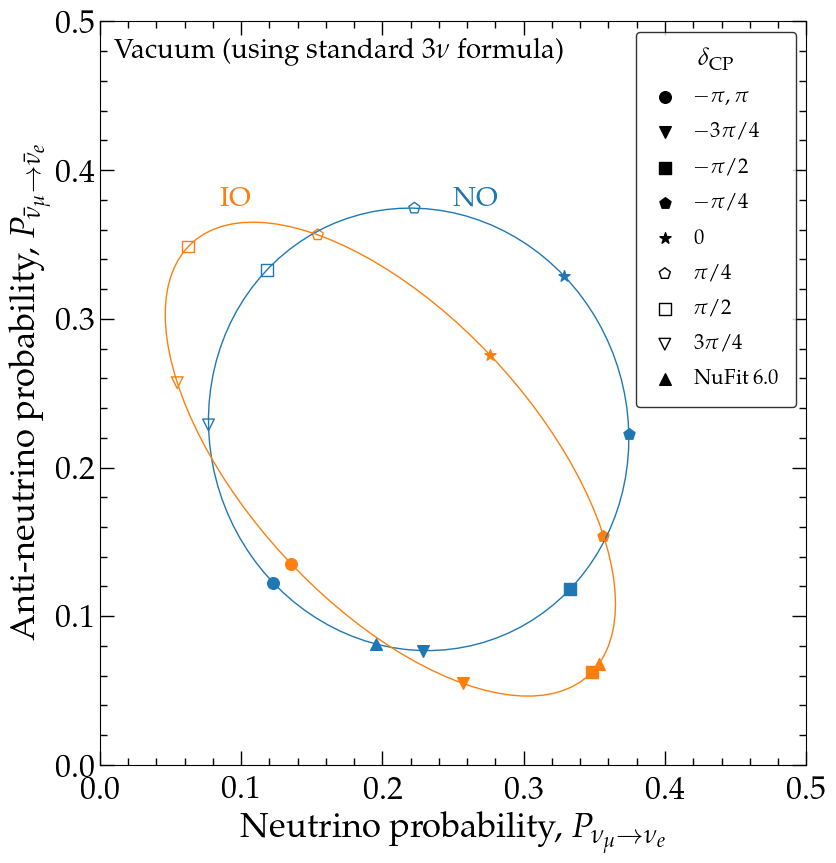

In [93]:
make_plot_biprobability([prob_nu_std_NO, prob_nu_std_IO], 
                        [prob_nubar_std_NO, prob_nubar_std_IO],
                        lc=['C0', 'C1'], ls=['-', '-'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'Vacuum (using standard $3\nu$ formula)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'NO', 'xy': (0.5,0.75), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.17,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'}
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.10),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.02),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0,0.50], ylim=[0,0.50], save_fig=False)

And this biprobability plot is, as expected, identical as the one produced using the Magnus expansion.

## In matter, long-baseline experiments (constant density, Earth's crust)

Now let's generate the biprobability plot in matter, for the NO$\nu$A, T2K, and DUNE long-baseline setups.  Compare the plots below to the ones shown in Fig. 7 of arXiv:1307.3248.

In [144]:
# ====== NOvA ======

# Pick the baseline and energy of NOvA
baseline = 810 # [km]
energy = 2*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Coherent matter potential in matter
rho = 3.0 # Average matter density in the Earth's crus [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Note: we could have directly used VCC = gd.NUM_DENSITY_E_EARTH_CRUST

# Hamiltonian in matter
H_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False)
    + H_matt

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False)
    - H_matt

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

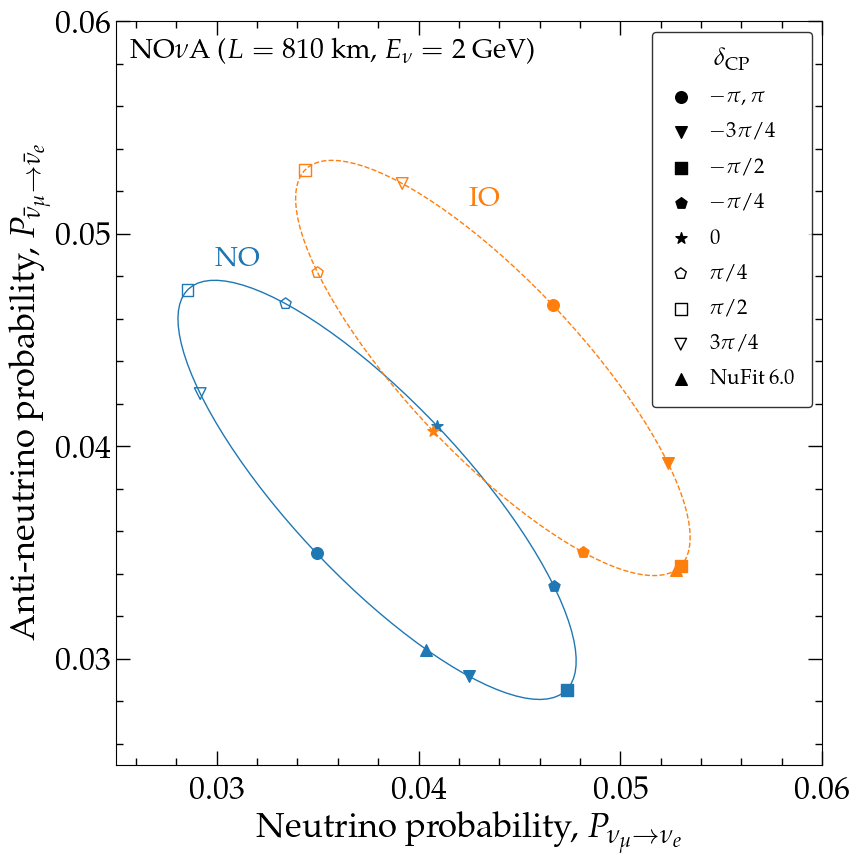

In [145]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '--'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'NO$\nu$A ($L = 810$~km, $E_\nu = 2$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'NO', 'xy': (0.14,0.67), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.5,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0.025,0.06], ylim=[0.025,0.06], save_fig=False)

In [142]:
# ====== T2K ======

# Pick the baseline and energy of T2K
baseline = 295 # [km]
energy = 0.6*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Coherent matter potential in matter
rho = 3.0 # Average matter density in the Earth's crus [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Note: we could have directly used VCC = gd.NUM_DENSITY_E_EARTH_CRUST

# Hamiltonian in matter
H_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False)
    + H_matt

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False)
    - H_matt

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

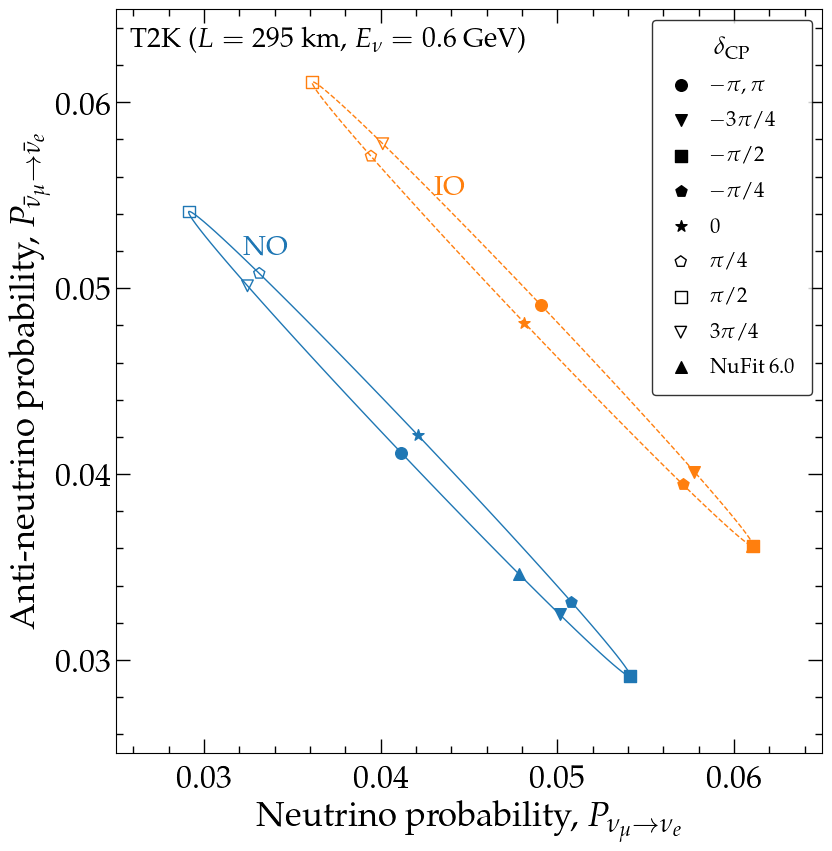

In [143]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '--'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'T2K ($L = 295$~km, $E_\nu = 0.6$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'NO', 'xy': (0.18,0.67), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.45,0.75), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0.025,0.065], ylim=[0.025,0.065], save_fig=False)

In [135]:
# ====== DUNE ======

# Pick the baseline and energy of DUNE
baseline = 1300 # [km]
energy = 2*gd.UNIT_GEV # [eV]

# Values of the delta_CP phase at which to compute the probabilities
dCP_npts = 100
dCP_arr = np.linspace(-np.pi, np.pi, dCP_npts)

# We will compute the appearance probabilities, i.e., nu_mu --> nu_e and nu_mu-bar --> nu_e-bar
nu_i, nu_f = gd.NUMU, gd.NUE

# Coherent matter potential in matter
rho = 3.0 # Average matter density in the Earth's crus [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]
# Note: we could have directly used VCC = gd.NUM_DENSITY_E_EARTH_CRUST

# Hamiltonian in matter
H_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)

# Hamiltonian for neutrinos (the matter potential is added)
def H_nu(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=False, compute_matrix_multiplication=False)
    + H_matt

# Hamiltonian for anti-neutrinos (the matter potential is subtracted)
def H_nubar(s12, s23, s13, dCP, D21, D31):
    return hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31, nubar=True, compute_matrix_multiplication=False)
    - H_matt

# Generate the neutrino and anti-neutrino oscillation probabilities for many different values of dCP
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
# nu_mu --> nu_e, normal ordering
prob_nu_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, normal ordering
prob_nubar_NO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu --> nu_e, inverted ordering
prob_nu_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                    0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                    n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                    integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])
# nu_mu-bar --> nu_e-bar, inverted ordering
prob_nubar_IO = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO),
                                                       0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                       n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                       integration_method='simpson', n_jobs=1)[nu_i][nu_f]] for dCP in dCP_arr])

# Points for selected values of dCP
dCP_sel = [-np.pi, -0.75*np.pi, -0.5*np.pi, -0.25*np.pi, 0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi]
dCP_label_sel = [r'$-\pi, \pi$', r'$-3\pi/4$', r'$-\pi/2$', r'$-\pi/4$', r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', 'NuFit 6.0']
markers = ['o', 'v', 's', 'p', '*', 'p', 's', 'v', '^']
filled = [True, True, True, True, True, False, False, False, True]
prob_nu_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]] 
                           for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nubar_NO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_NO, s23_NO, s13_NO, dCP, D21_NO, D31_NO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_NO_BF_NUFIT_6_0]])
prob_nu_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nu(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                        0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                        n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                        integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                           for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
prob_nubar_IO_sel = np.array([[dCP/np.pi, oscprob.osc_prob(lambda l: H_nubar(s12_IO, s23_IO, s13_IO, dCP, D21_IO, D31_IO), 
                                                           0.0, baseline*gd.CONV_KM_TO_INV_EV, 
                                                           n_slabs=1, n_tpts_per_slab=2, magnus_exp_order=1,
                                                           integration_method='simpson', n_jobs=1)[nu_i][nu_f]]
                              for dCP in dCP_sel+[gd.DCP_IO_BF_NUFIT_6_0]])
points_NO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_NO_sel[i][1], prob_nubar_NO_sel[i][1]]] for i in range(len(dCP_sel)+1)]
points_IO_sel = [[dCP_label_sel[i], markers[i], filled[i], [prob_nu_IO_sel[i][1], prob_nubar_IO_sel[i][1]]] for i in range(len(dCP_sel)+1)]

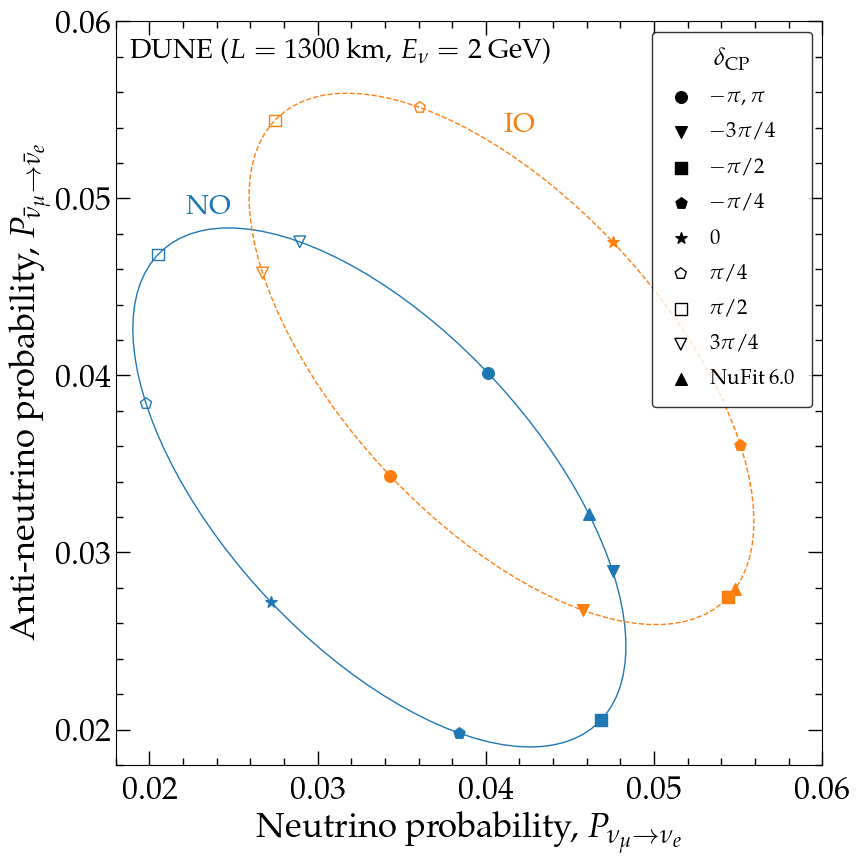

In [141]:
make_plot_biprobability([prob_nu_NO, prob_nu_IO], 
                        [prob_nubar_NO, prob_nubar_IO],
                        lc=['C0', 'C1'], ls=['-', '--'], lw=[1.0, 1.0],
                        points_sel_arr=[points_NO_sel, points_IO_sel],
                        label_prob_nu=r'Neutrino probability, $P_{\nu_\mu \to \nu_e}$', 
                        label_prob_nubar=r'Anti-neutrino probability, $P_{\bar{\nu}_\mu \to \bar{\nu}_e}$',
                        annotations=[
                            {'text': r'DUNE ($L = 1300$~km, $E_\nu = 2$~GeV)', 'xy': (0.02,0.95), 'color': 'k', 'fontsize': 20, 
                             'ha': 'left'},
                            {'text': 'NO', 'xy': (0.10,0.74), 'color': 'C0', 'fontsize': 20, 'ha': 'left'},
                            {'text': 'IO', 'xy': (0.55,0.85), 'color': 'C1', 'fontsize': 20, 'ha': 'left'},
                        ], 
                        xaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        xaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        yaxis_major_locator=mpl.ticker.MultipleLocator(base=0.01),
                        yaxis_minor_locator=mpl.ticker.MultipleLocator(base=0.002),
                        leg_fontsize=15, leg_loc='upper right', leg_ncol=1, xlim=[0.018,0.06], ylim=[0.018,0.06], save_fig=False)

## In matter, through the Earth (PREM)

## In matter, exponentially falling density profile